# MiniMak TBR Wedge — Local Test Notebook

Runs the same logic as `minimak_tbr_wedge.py` step-by-step so each stage can be inspected.

**Requirements:** `openmc`, `numpy`, `matplotlib`  
Install if needed: `pip install openmc matplotlib`

## 1. Parameters

In [1]:
import math
import json
import numpy as np
import matplotlib.pyplot as plt
import openmc

# --- Primary parameters (edit these) ---
MAJOR_RADIUS_M   = 0.23     # R0 [m]
MINOR_RADIUS_M   = 0.045    # plasma minor radius [m]
FIRST_WALL_GAP_M = 0.025    # standoff from plasma edge to blanket inner face [m]
BLANKET_THICK_M  = 0.05     # blanket thickness [m]  <-- sweep this
LI6_ENRICHMENT   = 0.075    # Li-6 atom fraction (natural = 0.075)

# --- Run settings ---
N_PARTICLES = 10_000   # keep small for a quick local test
N_BATCHES   = 30
N_INACTIVE  = 5
N_THREADS   = 4
WEDGE_DEG   = 10.0

# --- Derived (OpenMC uses cm) ---
R0_cm   = MAJOR_RADIUS_M   * 100
a_cm    = MINOR_RADIUS_M   * 100
fw_cm   = FIRST_WALL_GAP_M * 100
t_b_cm  = BLANKET_THICK_M  * 100

fw_inner_cm     = a_cm + fw_cm
fw_outer_cm     = fw_inner_cm + t_b_cm
vessel_outer_cm = fw_outer_cm + 5.0
half_wedge_rad  = math.radians(WEDGE_DEG / 2.0)

print(f"Plasma torus:  R0={R0_cm:.1f} cm  a={a_cm:.1f} cm")
print(f"Blanket inner: {fw_inner_cm:.1f} cm   outer: {fw_outer_cm:.1f} cm")
print(f"Wedge: ±{WEDGE_DEG/2}°")

Plasma torus:  R0=23.0 cm  a=4.5 cm
Blanket inner: 7.0 cm   outer: 12.0 cm
Wedge: ±5.0°


## 2. Materials

In [2]:
# Vacuum placeholder for plasma region
vacuum = openmc.Material(name="vacuum")
vacuum.add_nuclide("He4", 1.0)
vacuum.set_density("g/cm3", 1e-10)

# FLiBe (Li2BeF4)  density ~1.94 g/cm3 at operating temp
flibe = openmc.Material(name="FLiBe")
flibe.set_density("g/cm3", 1.94)
flibe.add_nuclide("Li6",  LI6_ENRICHMENT       * 2, "ao")
flibe.add_nuclide("Li7", (1 - LI6_ENRICHMENT)  * 2, "ao")
flibe.add_nuclide("Be9",  1.0,                       "ao")
flibe.add_nuclide("F19",  4.0,                       "ao")

materials = openmc.Materials([vacuum, flibe])
materials.export_to_xml()
print("Materials exported")
print(flibe)

Materials exported
Material
	ID             =	2
	Name           =	FLiBe
	Temperature    =	None
	Density        =	1.94 [g/cm3]
	Volume         =	None [cm^3]
	Depletable     =	False
	S(a,b) Tables  
	Nuclides       
	Li6            =	0.15         [ao]
	Li7            =	1.85         [ao]
	Be9            =	1.0          [ao]
	F19            =	4.0          [ao]



## 3. Geometry — CSG torus wedge

Three nested torus surfaces define plasma / blanket / vessel.  
Two reflective planes cut out the 10° wedge.

In [3]:
# Torus surfaces  (ZTorus: axis = Z, centred at origin)
plasma_torus  = openmc.ZTorus(x0=0, y0=0, z0=0, a=R0_cm, b=a_cm,             c=a_cm)
blanket_torus = openmc.ZTorus(x0=0, y0=0, z0=0, a=R0_cm, b=fw_outer_cm,      c=fw_outer_cm)
vessel_torus  = openmc.ZTorus(x0=0, y0=0, z0=0, a=R0_cm, b=vessel_outer_cm,  c=vessel_outer_cm)

# Reflective wedge planes through the origin
# Normal vectors rotated ±half_wedge from the x-axis in the x-y plane
plane_pos = openmc.Plane(
    a= math.sin(half_wedge_rad), b=-math.cos(half_wedge_rad), c=0, d=0,
    boundary_type="reflective")
plane_neg = openmc.Plane(
    a=-math.sin(half_wedge_rad), b=-math.cos(half_wedge_rad), c=0, d=0,
    boundary_type="reflective")

# Outer vacuum sphere
outer_sphere = openmc.Sphere(r=vessel_outer_cm + R0_cm + 10, boundary_type="vacuum")

# The wedge interior region
wedge_interior = +plane_pos & -plane_neg & -outer_sphere

# Cells
plasma_cell  = openmc.Cell(name="plasma",       fill=vacuum, region=-plasma_torus  & wedge_interior)
blanket_cell = openmc.Cell(name="blanket",       fill=flibe,  region=+plasma_torus  & -blanket_torus & wedge_interior)
vessel_cell  = openmc.Cell(name="vessel_shell",  fill=None,   region=+blanket_torus & -vessel_torus  & wedge_interior)
outer_void   = openmc.Cell(name="outer_void",    fill=None,   region=+vessel_torus  & wedge_interior)

universe = openmc.Universe(cells=[plasma_cell, blanket_cell, vessel_cell, outer_void])
geometry = openmc.Geometry(universe)
geometry.export_to_xml()
print("Geometry exported")

Geometry exported


### 3a. Quick geometry check — 2D cross-section plot

 Reading materials XML file...
 Reading geometry XML file...
 Preparing distributed cell instances...
 Reading plot XML file...

 =======================>     PLOTTING SUMMARY     <========================

Plot ID: 1
Plot file: plot_1.png
Universe depth: -1
Plot Type: Slice
Origin: 23 0 0
Width:   44   44
Coloring: Materials
Basis: XZ
Pixels: 600 600

 Processing plot 1: plot_1.png...


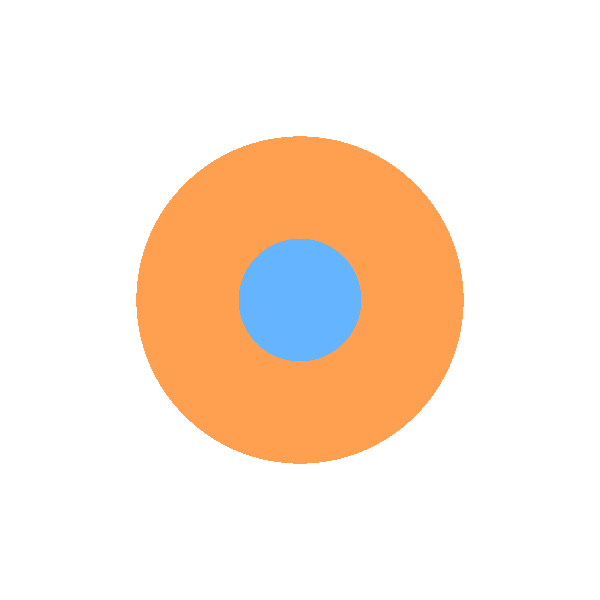

In [4]:
# Plot the R-Z cross section through the mid-plane of the wedge (y=0)
# Shows plasma (blue), blanket (orange), void (white)
plot = openmc.Plot()
plot.basis      = 'xz'
plot.origin     = (R0_cm, 0, 0)
plot.width      = (vessel_outer_cm * 2 + 10, vessel_outer_cm * 2 + 10)
plot.pixels     = (600, 600)
plot.color_by   = 'material'
plot.colors     = {vacuum: (100, 180, 255), flibe: (255, 160, 80)}
plots = openmc.Plots([plot])
plots.export_to_xml()
openmc.plot_geometry()

from IPython.display import Image
Image('plot_1.png')

## 4. Neutron source

14.1 MeV isotropic D-T source uniformly distributed in the plasma torus volume.

In [ ]:
# Rejection-sampled toroidal source using OpenMC's built-in cell domain filtering.
#
# source.domains = [plasma_cell] tells OpenMC to sample from the bounding Box
# but reject any point that falls outside the plasma_cell region.
# The result is a source uniform within the true torus cross-section.
#
# TODO: upgrade to a peaked plasma density profile (parabolic or Gaussian in
#       minor radius) to better represent the fusion reaction rate distribution.
#       This matters most for first-wall heat load calculations; the effect on
#       global TBR is secondary.

source = openmc.IndependentSource()
source.space = openmc.stats.Box(
    lower_left=(R0_cm - a_cm, -a_cm, -a_cm),
    upper_right=(R0_cm + a_cm,  a_cm,  a_cm),
)
source.domains = [plasma_cell]   # reject samples outside the torus — rejection sampling
source.angle   = openmc.stats.Isotropic()
source.energy  = openmc.stats.Discrete([14.1e6], [1.0])

print(f"Source: Box + cell rejection (uniform within plasma torus)")
print(f"  Bounding box: R={R0_cm-a_cm:.1f}–{R0_cm+a_cm:.1f} cm, Z=±{a_cm:.1f} cm")
print(f"  Source energy: 14.1 MeV isotropic")


## 5. Settings

In [ ]:
import os
os.environ["OPENMC_CROSS_SECTIONS"] = "/Users/anthony/1.multiphysics/nuclear_data/cross_sections.xml"
print("Cross sections:", os.environ["OPENMC_CROSS_SECTIONS"])

In [ ]:
settings = openmc.Settings()
settings.source    = source
settings.batches   = N_BATCHES
settings.inactive  = N_INACTIVE
settings.particles = N_PARTICLES
settings.run_mode  = "fixed source"
settings.export_to_xml()
print(f"Settings: {N_BATCHES} batches × {N_PARTICLES:,} particles ({N_INACTIVE} inactive)")

## 6. Tallies — TBR via (n,Xt)

In [ ]:
trit_tally = openmc.Tally(name="TBR")
trit_tally.filters = [openmc.CellFilter(blanket_cell)]
trit_tally.scores  = ["(n,Xt)"]

tallies = openmc.Tallies([trit_tally])
tallies.export_to_xml()
print("Tally: (n,Xt) reaction rate in blanket cell")

## 7. Run

In [ ]:
openmc.run(threads=N_THREADS)

## 8. Extract TBR result

In [ ]:
import glob

sp_file = sorted(glob.glob("statepoint.*.h5"))[-1]
print(f"Reading {sp_file}")

sp = openmc.StatePoint(sp_file)
t  = sp.get_tally(name="TBR")

tbr_mean = float(t.mean.flatten()[0])
tbr_std  = float(t.std_dev.flatten()[0])

print(f"\n{'='*40}")
print(f"  TBR = {tbr_mean:.4f} ± {tbr_std:.4f}")
print(f"{'='*40}")
print(f"  Blanket: {BLANKET_THICK_M*100:.0f} cm FLiBe  (Li-6 {LI6_ENRICHMENT*100:.1f}%)")
print(f"  R0={MAJOR_RADIUS_M} m  a={MINOR_RADIUS_M} m")

In [ ]:
import subprocess, os, json, tempfile

TOOL_DIR = os.path.dirname(os.path.abspath("minimak_tbr_wedge.py"))

thicknesses = [0.05, 0.10, 0.15, 0.20, 0.25, 0.30]
tbr_values  = []
tbr_errors  = []

env = os.environ.copy()
env["OPENMC_CROSS_SECTIONS"] = "/Users/anthony/1.multiphysics/nuclear_data/cross_sections.xml"

for t_m in thicknesses:
    # Each run gets its own temp dir so OpenMC output files don't conflict
    with tempfile.TemporaryDirectory() as run_dir:
        out_file = os.path.join(run_dir, f"tbr_{int(t_m*100)}cm.json")
        result = subprocess.run(
            ["python", os.path.join(TOOL_DIR, "minimak_tbr_wedge.py"),
             "--blanket-thick", str(t_m),
             "--particles",     str(N_PARTICLES),
             "--batches",       str(N_BATCHES),
             "--output",        out_file],
            capture_output=True, text=True, cwd=run_dir, env=env
        )
        if result.returncode != 0:
            print(f"  t={t_m*100:.0f} cm  FAILED:")
            print(result.stderr[-1000:])
            continue
        with open(out_file) as f2:
            r = json.load(f2)
    tbr_values.append(r["TBR"])
    tbr_errors.append(r["TBR_std"])
    print(f"  t={t_m*100:.0f} cm  TBR = {r['TBR']:.4f} +/- {r['TBR_std']:.4f}")

if tbr_values:
    fig, ax = plt.subplots(figsize=(7, 4))
    ax.errorbar([thicknesses[i]*100 for i in range(len(tbr_values))], tbr_values,
                yerr=tbr_errors, fmt='o-', capsize=4, color='steelblue')
    ax.axhline(1.0,  color='red',    linestyle='--', label='TBR = 1.0 (breakeven)')
    ax.axhline(1.05, color='orange', linestyle='--', label='TBR = 1.05 (target)')
    ax.set_xlabel("Blanket thickness (cm)")
    ax.set_ylabel("TBR")
    ax.set_title("MiniMak FLiBe Blanket TBR vs Thickness")
    ax.legend()
    ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig(os.path.join(TOOL_DIR, "tbr_sweep.png"), dpi=150)
    plt.show()


## 10. Li-6 Enrichment Sweep

Fixes blanket thickness at 20 cm and sweeps Li-6 enrichment from natural (7.5%) to fully enriched (95%).
This shows whether enrichment alone can push TBR > 1.0 at MiniMak scale.

In [ ]:
import subprocess, os, json, tempfile

TOOL_DIR = os.path.dirname(os.path.abspath("minimak_tbr_wedge.py"))

enrichments   = [0.075, 0.10, 0.20, 0.30, 0.50, 0.75, 0.95]
tbr_enrich    = []
tbr_enrich_err = []

SWEEP_BLANKET_THICK = 0.20   # fix blanket at 20 cm for this sweep
SWEEP_BE_THICK      = 0.0    # no Be for now — pure enrichment effect

env = os.environ.copy()
env["OPENMC_CROSS_SECTIONS"] = "/Users/anthony/1.multiphysics/nuclear_data/cross_sections.xml"

for enr in enrichments:
    with tempfile.TemporaryDirectory() as run_dir:
        out_file = os.path.join(run_dir, f"tbr_li6_{int(enr*100)}.json")
        result = subprocess.run(
            ["python", os.path.join(TOOL_DIR, "minimak_tbr_wedge.py"),
             "--blanket-thick",  str(SWEEP_BLANKET_THICK),
             "--be-thick",       str(SWEEP_BE_THICK),
             "--li6-enrichment", str(enr),
             "--particles",      str(N_PARTICLES),
             "--batches",        str(N_BATCHES),
             "--output",         out_file],
            capture_output=True, text=True, cwd=run_dir, env=env
        )
        if result.returncode != 0:
            print(f"  Li-6={enr*100:.0f}%  FAILED:")
            print(result.stderr[-800:])
            continue
        with open(out_file) as f2:
            r = json.load(f2)
    tbr_enrich.append(r["TBR"])
    tbr_enrich_err.append(r["TBR_std"])
    print(f"  Li-6={enr*100:.0f}%  TBR = {r['TBR']:.4f} +/- {r['TBR_std']:.4f}")

# --- Also run a Be sweep at natural enrichment for comparison ---
print("\nBeryllium multiplier sweep (natural Li-6, 20 cm FLiBe):")
be_thicknesses = [0.0, 0.01, 0.02, 0.03, 0.05, 0.10]
tbr_be    = []
tbr_be_err = []

for be in be_thicknesses:
    with tempfile.TemporaryDirectory() as run_dir:
        out_file = os.path.join(run_dir, f"tbr_be_{int(be*100)}cm.json")
        result = subprocess.run(
            ["python", os.path.join(TOOL_DIR, "minimak_tbr_wedge.py"),
             "--blanket-thick",  str(SWEEP_BLANKET_THICK),
             "--be-thick",       str(be),
             "--li6-enrichment", "0.075",
             "--particles",      str(N_PARTICLES),
             "--batches",        str(N_BATCHES),
             "--output",         out_file],
            capture_output=True, text=True, cwd=run_dir, env=env
        )
        if result.returncode != 0:
            print(f"  Be={be*100:.0f}mm  FAILED:")
            print(result.stderr[-800:])
            continue
        with open(out_file) as f2:
            r = json.load(f2)
    tbr_be.append(r["TBR"])
    tbr_be_err.append(r["TBR_std"])
    print(f"  Be={be*100:.0f} mm  TBR = {r['TBR']:.4f} +/- {r['TBR_std']:.4f}")

# --- Plot both ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))

ax1.errorbar([e*100 for e in enrichments], tbr_enrich, yerr=tbr_enrich_err,
             fmt='o-', capsize=4, color='steelblue')
ax1.axhline(1.0,  color='red',    linestyle='--', label='TBR = 1.0')
ax1.axhline(1.05, color='orange', linestyle='--', label='TBR = 1.05 target')
ax1.set_xlabel("Li-6 enrichment (%)")
ax1.set_ylabel("TBR")
ax1.set_title(f"TBR vs Li-6 Enrichment\n(FLiBe {SWEEP_BLANKET_THICK*100:.0f} cm, no Be)")
ax1.legend()
ax1.grid(alpha=0.3)

ax2.errorbar([b*10 for b in be_thicknesses], tbr_be, yerr=tbr_be_err,
             fmt='s-', capsize=4, color='seagreen')
ax2.axhline(1.0,  color='red',    linestyle='--', label='TBR = 1.0')
ax2.axhline(1.05, color='orange', linestyle='--', label='TBR = 1.05 target')
ax2.set_xlabel("Beryllium thickness (mm)")
ax2.set_ylabel("TBR")
ax2.set_title(f"TBR vs Be Multiplier Thickness\n(FLiBe {SWEEP_BLANKET_THICK*100:.0f} cm, natural Li-6)")
ax2.legend()
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(TOOL_DIR, "tbr_enrichment_be_sweep.png"), dpi=150)
plt.show()


## 11. Material Comparison — FLiBe vs Pb-16Li vs Pure Li

Sweeps blanket thickness for all three materials at natural Li-6 enrichment.
Shows how material choice affects TBR independently of thickness.

In [ ]:
import subprocess, os, json, tempfile

TOOL_DIR = os.path.dirname(os.path.abspath("minimak_tbr_wedge.py"))

materials   = ["flibe", "pbli", "li"]
mat_labels  = {"flibe": "FLiBe (Li₂BeF₄)", "pbli": "Pb-16Li eutectic", "li": "Pure Li"}
mat_colours = {"flibe": "steelblue",        "pbli": "tomato",           "li": "seagreen"}

thicknesses = [0.05, 0.10, 0.15, 0.20, 0.25, 0.30]

env = os.environ.copy()
env["OPENMC_CROSS_SECTIONS"] = "/Users/anthony/1.multiphysics/nuclear_data/cross_sections.xml"

results = {m: {"tbr": [], "err": []} for m in materials}

for mat in materials:
    print(f"\n--- {mat_labels[mat]} ---")
    for t_m in thicknesses:
        with tempfile.TemporaryDirectory() as run_dir:
            out_file = os.path.join(run_dir, "result.json")
            result = subprocess.run(
                ["python", os.path.join(TOOL_DIR, "minimak_tbr_wedge.py"),
                 "--blanket-material", mat,
                 "--blanket-thick",    str(t_m),
                 "--li6-enrichment",   "0.075",
                 "--particles",        str(N_PARTICLES),
                 "--batches",          str(N_BATCHES),
                 "--output",           out_file],
                capture_output=True, text=True, cwd=run_dir, env=env
            )
            if result.returncode != 0:
                print(f"  t={t_m*100:.0f} cm  FAILED:")
                print(result.stderr[-500:])
                results[mat]["tbr"].append(None)
                results[mat]["err"].append(None)
                continue
            with open(out_file) as f2:
                r = json.load(f2)
        results[mat]["tbr"].append(r["TBR"])
        results[mat]["err"].append(r["TBR_std"])
        print(f"  t={t_m*100:.0f} cm  TBR = {r['TBR']:.4f} +/- {r['TBR_std']:.4f}")

# --- Plot ---
fig, ax = plt.subplots(figsize=(8, 5))

for mat in materials:
    tbr = results[mat]["tbr"]
    err = results[mat]["err"]
    valid = [(t, v, e) for t, v, e in zip(thicknesses, tbr, err) if v is not None]
    if not valid:
        continue
    t_vals, tbr_vals, err_vals = zip(*valid)
    ax.errorbar([t*100 for t in t_vals], tbr_vals, yerr=err_vals,
                fmt='o-', capsize=4, label=mat_labels[mat],
                color=mat_colours[mat])

ax.axhline(1.0,  color='red',    linestyle='--', linewidth=1.2, label='TBR = 1.0 (breakeven)')
ax.axhline(1.05, color='orange', linestyle='--', linewidth=1.2, label='TBR = 1.05 (target)')
ax.set_xlabel("Blanket thickness (cm)")
ax.set_ylabel("TBR")
ax.set_title("MiniMak TBR — Material Comparison\n(natural Li-6 enrichment, no Be multiplier)")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(TOOL_DIR, "tbr_material_comparison.png"), dpi=150)
plt.show()
